In [1]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("mexwell/crop-diseases-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 2.00G/2.00G [01:40<00:00, 21.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mexwell/crop-diseases-classification/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/mexwell/crop-diseases-classification/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/mexwell/crop-diseases-classification/versions/1):
['Data']


In [2]:
import os

# Update path to match 'Data' directory found in the crop diseases dataset
data_path = os.path.join(path, 'Data')

# List subdirectories in Data (usually class labels)
if os.path.exists(data_path):
    print(f"Classes in dataset: {os.listdir(data_path)}")
else:
    print(f"Directory not found: {data_path}")

Classes in dataset: ['label_num_to_disease_map.json', 'train.csv', 'train_images']



--- Sample Images from Dataset (/root/.cache/kagglehub/datasets/mexwell/crop-diseases-classification/versions/1/Data) ---
Found 17938 images. Displaying 6 samples:


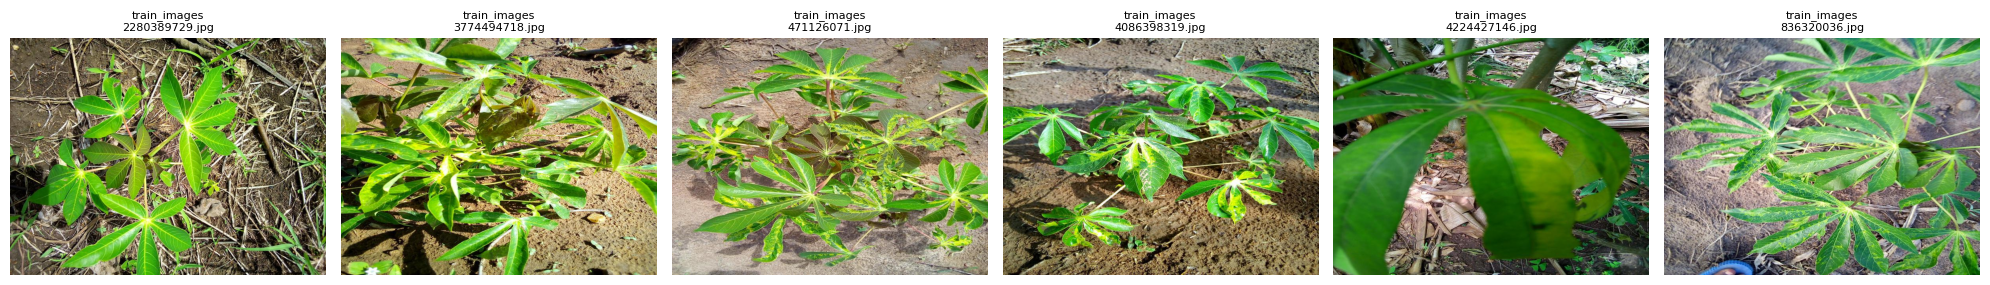

In [3]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} samples:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Display class name (parent directory) and filename
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the correct Data path
data_path = os.path.join(path, 'Data')
print(f"\n--- Sample Images from Dataset ({data_path}) ---")
display_sample_images(data_path)

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

# Paths to the CSV file and the image directory
csv_path = os.path.join(data_path, 'train.csv')
image_dir = os.path.join(data_path, 'train_images')

# Read data from CSV
df = pd.read_csv(csv_path)

print(f"Original DataFrame length: {len(df)}")

# Map all existing files on disk for fast lookup
# This handles cases where images might be in subfolders or flat
print("Mapping existing files...")
existing_files_map = {}
for root, _, files in os.walk(image_dir):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            existing_files_map[file] = os.path.join(root, file)

# Filter DataFrame based on files actually found on disk
def find_path(row):
    img_id = str(row['image_id'])
    if not img_id.endswith('.jpg'):
        img_id += '.jpg'
    return existing_files_map.get(img_id)

df['actual_path'] = df.apply(find_path, axis=1)
df_filtered = df.dropna(subset=['actual_path']).copy()

print(f"Filtered DataFrame length: {len(df_filtered)}")

if len(df_filtered) > 0:
    # Split the FILTERED dataset
    train_df, test_df = train_test_split(
        df_filtered,
        test_size=0.2,
        random_state=42,
        stratify=df_filtered['label']
    )
    print(f"Number of training samples: {len(train_df)}")
    print(f"Number of test samples: {len(test_df)}")
    display(train_df.head())
else:
    print("Error: No matching images found on disk. Please check image_dir content.")

Original DataFrame length: 21397
Mapping existing files...
Filtered DataFrame length: 17938
Number of training samples: 14350
Number of test samples: 3588


,image_id,label,actual_path
20362,800593866.jpg,3,/root/.cache/kagglehub/datasets/mexwell/crop-d...
3730,1660311563.jpg,2,/root/.cache/kagglehub/datasets/mexwell/crop-d...
18139,4266959009.jpg,4,/root/.cache/kagglehub/datasets/mexwell/crop-d...
19991,726818817.jpg,0,/root/.cache/kagglehub/datasets/mexwell/crop-d...
9014,2595067395.jpg,3,/root/.cache/kagglehub/datasets/mexwell/crop-d...


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
import time

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


In [12]:
class CropDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Use the pre-calculated actual_path from our filtering step
        img_path = self.df.iloc[idx]['actual_path']
        label = int(self.df.iloc[idx]['label'])

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# Transformations for AlexNet (requires 224x224)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Note: We don't need image_dir here anymore as actual_path is absolute
train_dataset = CropDataset(train_df, transform=transform)
test_dataset = CropDataset(test_df, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Build AlexNet model
model = models.alexnet(num_classes=len(df_filtered['label'].unique()))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training Loop
num_epochs = 10
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print("Starting Training...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_val_loss = val_loss / len(test_loader)
    epoch_acc = 100 * correct / total

    history['train_loss'].append(epoch_loss)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_acc)

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_acc:.2f}%')

Starting Training...
Epoch [1/10], Loss: 1.0970, Val Loss: 1.0003, Val Acc: 63.94%
Epoch [2/10], Loss: 0.9900, Val Loss: 0.9835, Val Acc: 64.07%
Epoch [3/10], Loss: 0.9502, Val Loss: 0.9491, Val Acc: 65.30%
Epoch [4/10], Loss: 0.9285, Val Loss: 0.9447, Val Acc: 66.53%
Epoch [5/10], Loss: 0.9031, Val Loss: 0.9644, Val Acc: 66.33%
Epoch [6/10], Loss: 0.8612, Val Loss: 0.9259, Val Acc: 65.97%
Epoch [7/10], Loss: 0.8297, Val Loss: 0.8934, Val Acc: 67.95%
Epoch [8/10], Loss: 0.7984, Val Loss: 0.8587, Val Acc: 68.03%
Epoch [9/10], Loss: 0.7629, Val Loss: 0.8359, Val Acc: 69.43%
Epoch [10/10], Loss: 0.7250, Val Loss: 0.8785, Val Acc: 68.73%


In [13]:
print("--- Training Summary ---")
print(f"Final Training Loss: {history['train_loss'][-1]:.4f}")
print(f"Final Validation Loss: {history['val_loss'][-1]:.4f}")
print(f"Final Validation Accuracy: {history['val_acc'][-1]:.2f}%")
print(f"Best Validation Accuracy: {max(history['val_acc']):.2f}%")

--- Training Summary ---
Final Training Loss: 0.7250
Final Validation Loss: 0.8785
Final Validation Accuracy: 68.73%
Best Validation Accuracy: 69.43%


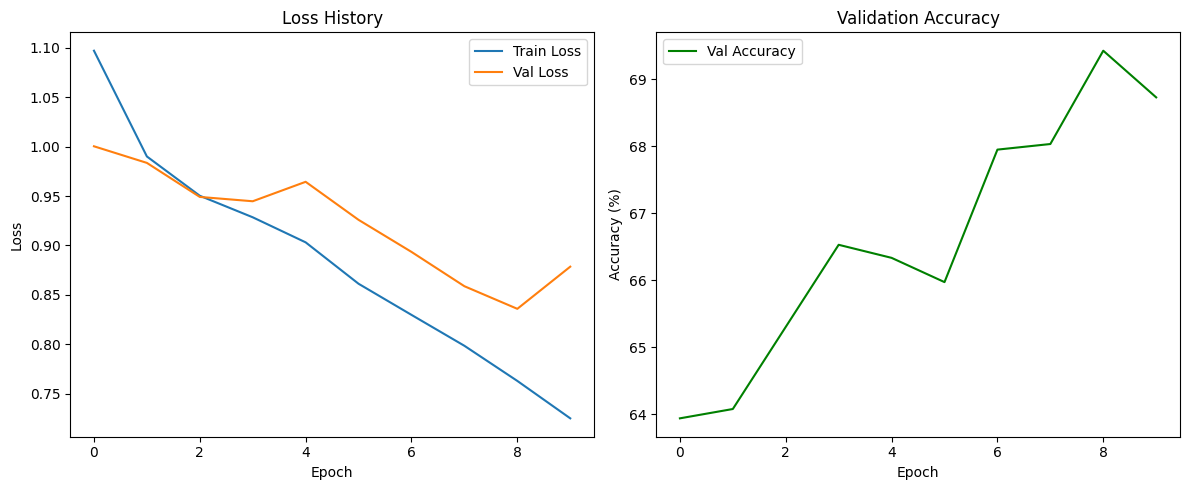

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['val_acc'], label='Val Accuracy', color='green')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()